In [1]:
import Reactions_plotting as rplt

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import glob
import re
import os
import time
import subprocess
from contextlib import contextmanager
from matplotlib.collections import PolyCollection

In [3]:
import Major_reactions as maj

In [4]:
# TARGET MOLECULES FOR EMISSION LINES
MOLEC = ["CO","CN","CS","HCN","HCO+","N2H+","CH3OH","H2CO"] 

In [5]:
# PATHS
chemistry_path = Path("/home/fmeyer/Stage/Model23/chemistry_final/")
thermal_path ="/home/fmeyer/Stage/Model23/thermal/"

In [6]:
# print(""" 0    : Gas phase reactions with GRAINS 
#  1    : Photodissoc/ionisation with cosmic rays
#  2    : Gas phase photodissoc/ionisations by secondary UV photons generated by CR
#  3    : Gas phase photodissociations/ionisations by UV
#  4-8  : Bimolecular gas phase reactions - several possible formula 
#  10-11: H2 formation on the grains when IS_GRAIN_REACTIONS eq 0
#  14   : Grain surface reactions
#  15   : Thermal evaporation
#  16   : Cosmic-ray evaporation
#  17-18: Photodissociations by Cosmic rays on grain surfaces
#  19-20: Photodissociations by UV photons on grain surfaces
#  21   : Grain surface reactions
#  66   : Photodesorption by external UV
#  67   : Photodesorption by CR generated UV
#  98   : storage of H2S under a refractory form
#  99   : Adsorption on grains""")

In [7]:
# PATHS
chemistry_path = Path("/home/fmeyer/Stage/Model23/chemistry_final/")
thermal_path ="/home/fmeyer/Stage/Model23/thermal/"

In [8]:
# Check if a results file exists, and create one if not or if overwrite = True
# The code can take a while to run, please be patient
results = maj.reactions(chemistry_path, thermal_path, MOLEC, r_lim=None, t_lim=None, z_arg="all", reac_type="major", write_file=True, overwrite=False)

The file already exists in /home/fmeyer/Stage/Model23/chemistry_final/major_reactions.parquet (Loading cached Parquet data...)


In [9]:
# Global summary of the results file
rplt.print_summary(results)

====================== CHEMICAL NETWORK SUMMARY ======================
Target Species Detected     : ['CO', 'CN', 'CS', 'HCN', 'HCO+', 'N2H+', 'CH3OH', 'H2CO']
Total Logged Database Rows  : 4,293,582
----------------------------------------------------------------------
RADIAL DOMAIN:
  * Radial Range (R)        : 5.0 to 280.0 AU
  * Unique Radii Count      : 33 grid points
----------------------------------------------------------------------
VERTICAL GEOMETRY & ASPECT RATIO (Z/R):
  * Absolute Height (Z)     : 0.000 to 71.20 AU
  * Global Aspect Ratio Z/R : 0.000 (Midplane/Inner) to 0.493 (Atmosphere/Outer)
    -> At R =   5 AU : Z max = 1.44 AU (Max Z/R = 0.288)
    -> At R =  10 AU : Z max = 3.29 AU (Max Z/R = 0.329)
    -> At R =  15 AU : Z max = 5.27 AU (Max Z/R = 0.351)
    ... [Truncated for brevity] ...
----------------------------------------------------------------------
AVERAGE THERMOPHYSICAL CONDITIONS CONTRAST:
  * Gas Temperature Range   : 11.2 K to 178.0 K
  * Gas Densi

In [49]:
# Information for a single spatial point
print(rplt.get_exact_data(results, radius_AU=50, position_AU=12, time_years=100, species="H2CO"))

    CHEMICAL & PHYSICAL DATA REPORT FOR H2CO
Query Coordinates : R=50 AU, Z=12 AU, t=100 yrs
Closest Grid Point : R=50.00 AU, Z=11.60 AU (Index #5)
Actual Time        : t=107.0 yrs
------------------------------------------------------------
PHYSICAL CONDITIONS AT THIS POINT:
  * gas_density            : 8640000.0
  * visual_extinction_Av   : 3.43
  * x_rate                 : 0.0
  * gas_temp_K             : 59.9
  * dust_temp_K            : 60.1
------------------------------------------------------------
PRODUCTION REACTIONS (4 pathways) :
  [4 ] O + CH3 -> H + H2CO            | Rate: 4.2043e-10 |  89.4%
  [4 ] HNC + H2COH+ -> H2CO + HCNH+   | Rate: 2.2697e-11 |   4.8%
  [4 ] O + H2CCN -> CN + H2CO         | Rate: 1.4943e-11 |   3.2%
  [15] J01H2CO -> H2CO                | Rate: 6.7734e-12 |   1.4%
------------------------------------------------------------
DESTRUCTION REACTIONS (8 pathways) :
  [3 ] H2CO -> CO + H2                | Rate: 3.9651e-10 |  31.9%
  [3 ] H2CO -> H + H + C

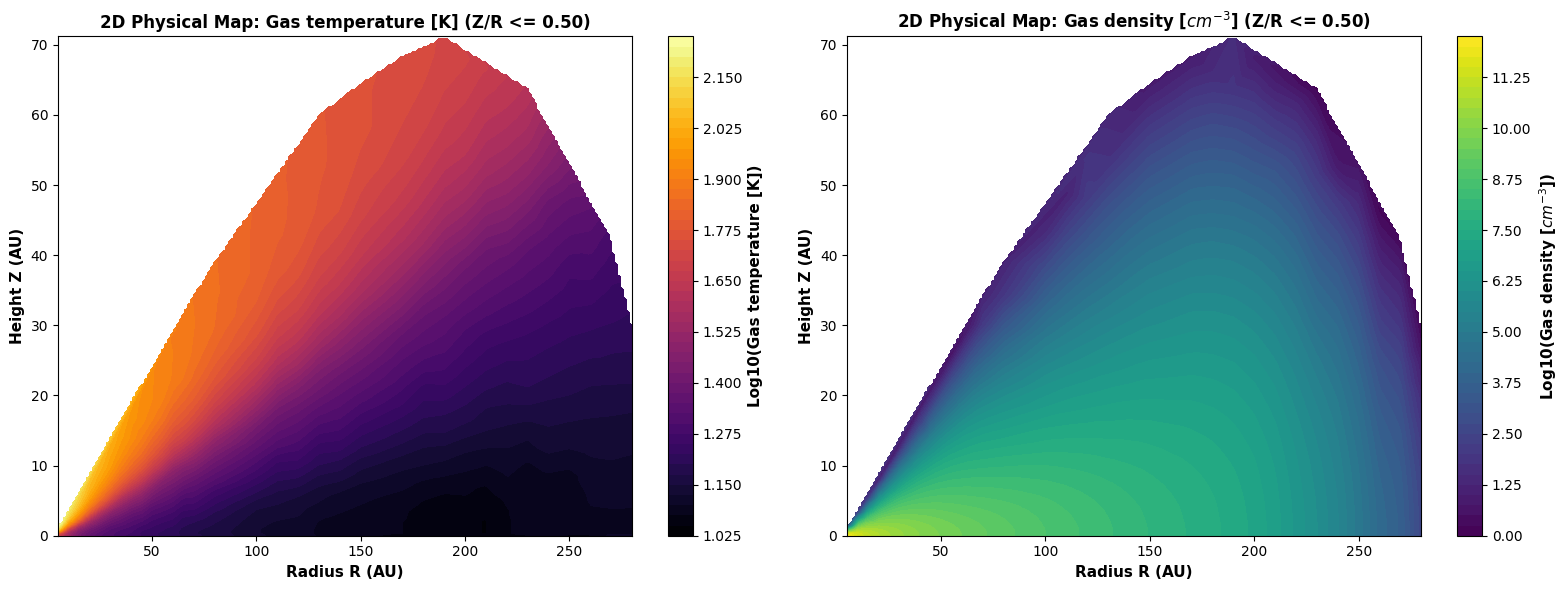

In [11]:
# # Physical parameters 2D maps
# rplt.plot_physical_map(results, param_names=['phys_gas_temp_K', 'phys_gas_density'],z_over_r_max=0.5,log_scale=True)

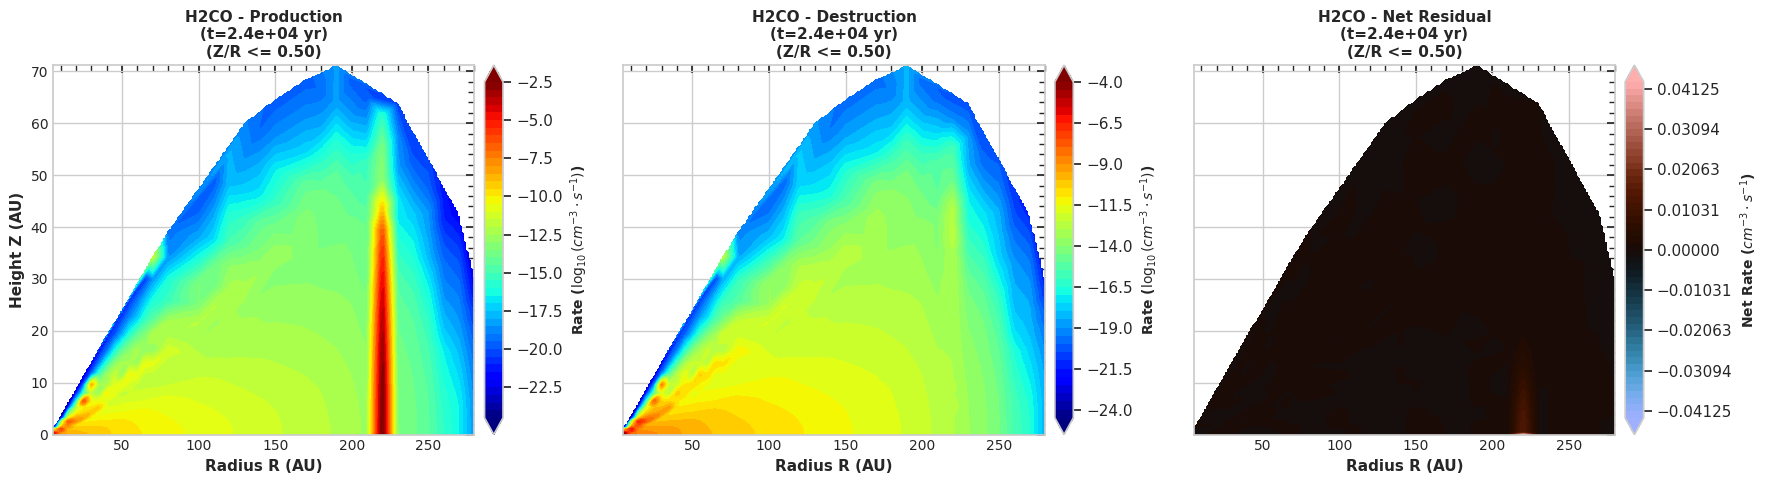

In [44]:
# 2D map of production and destruction rates for a chemical species
rplt.plot_chemical_maps(results, species="H2CO", time_years=24e3, z_over_r_max=0.5, average_time=False, log_scale=True, figsize=None, 
                   cmaps={'maps': 'jet', 'residual': 'berlin'})

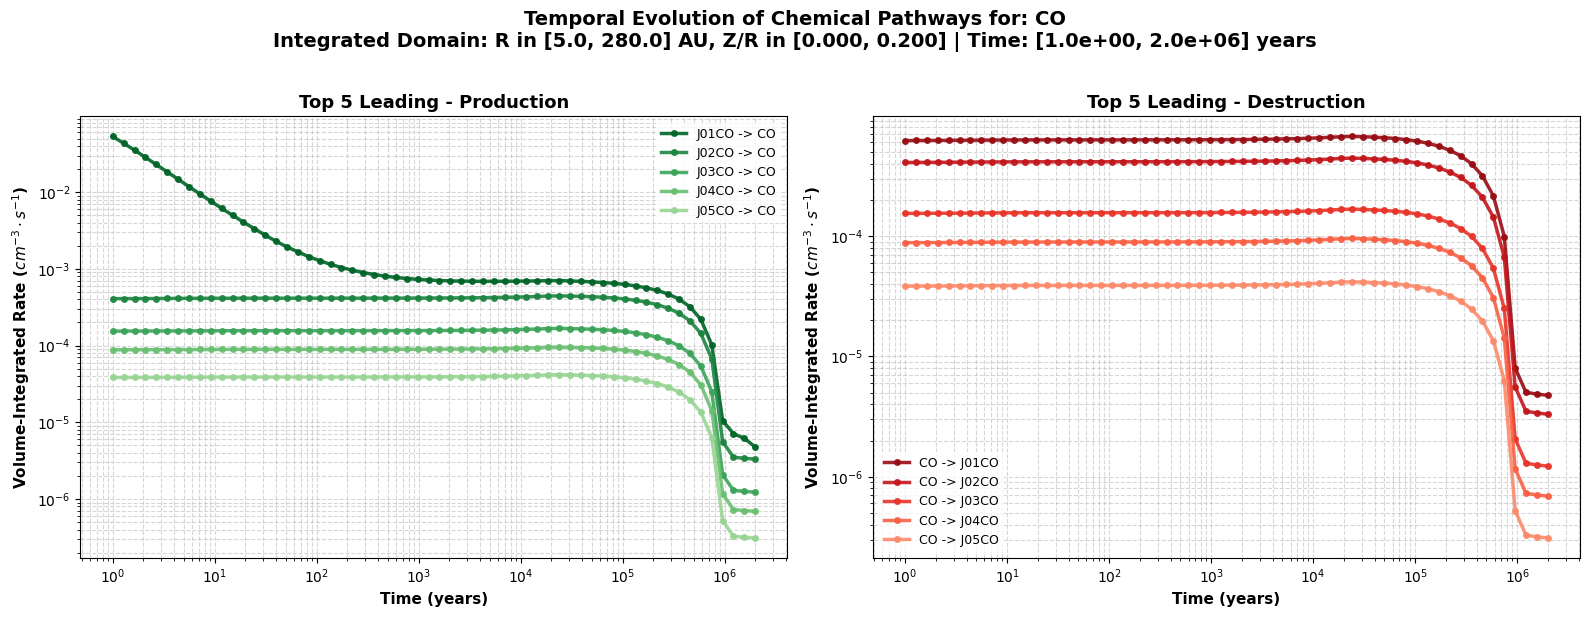

In [13]:
# Temporal evolution
rplt.plot_reaction_evolution(results, "CO", rmin=None, rmax=None, z_over_r_min=0, z_over_r_max=0.2,tmin=0,tmax=None, top_n=5)

-> Radial column isolation active. Closest grid radius matched: 20 AU


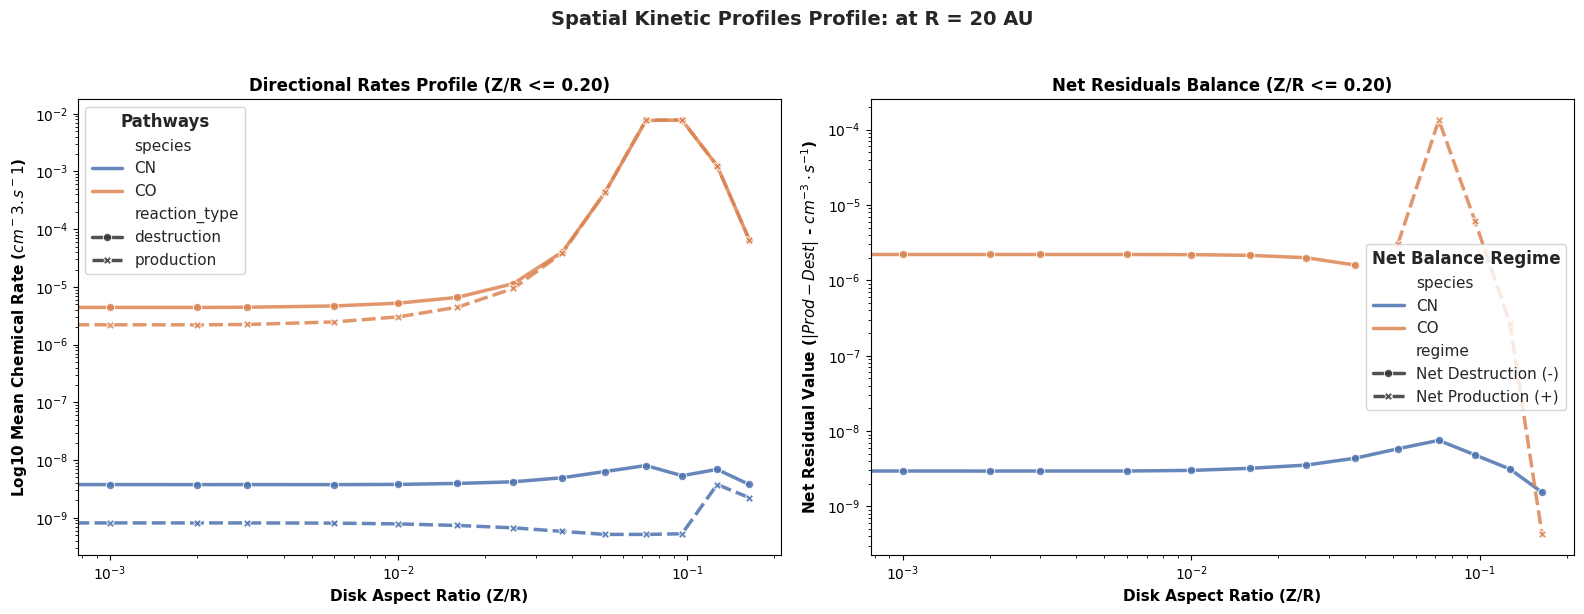

In [14]:
# Spatial kinetic profiles
rplt.plot_spatial_trends(results,z_over_r_max=0.2,species=['CO','CN'],radius_AU=20,log_scale=True)

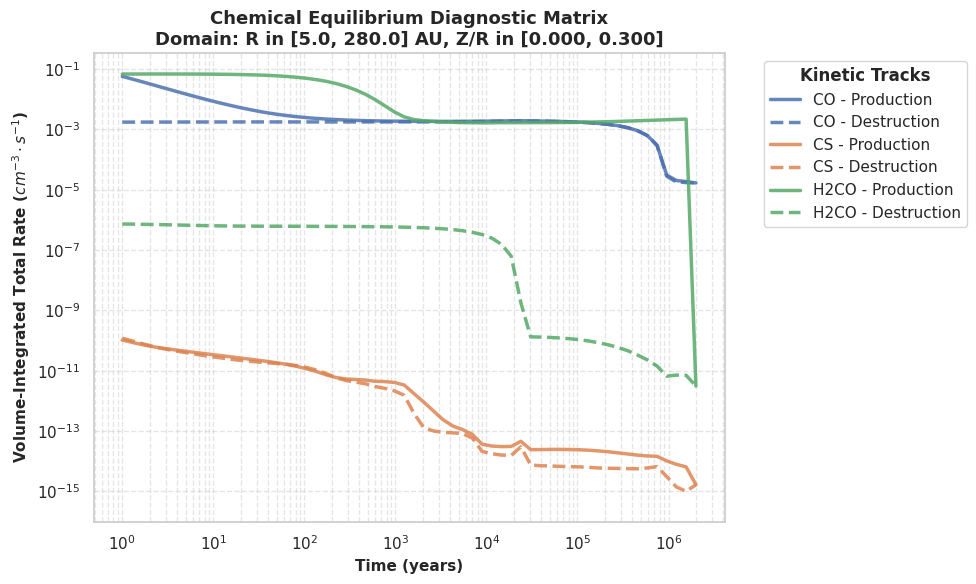

In [16]:
# Chemical equilibrium
rplt.plot_chemical_equilibrium(results ,["CO","CS","H2CO"] , rmin=None, rmax=None, z_over_r_min=None, z_over_r_max=0.3)